In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_3d_counts_to_cf
from scipy import constants

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18

In [3]:
cmap_map = 'plasma'

## Load data from local machine

In [4]:
fn_gcatlo = f'../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/mock2/mock_catalog_quaia_G20.fits'
fn_gcathi = f'../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/mock2/mock_catalog_quaia_G20.5.fits'

fn_gcatlo_nosel = f'../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/mock2/mock_catalog_quaia_nosel_G20.fits'
fn_gcathi_nosel = f'../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/mock2/mock_catalog_quaia_nosel_G20.5.fits'

## Parameters

In [5]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [6]:
name_catalog = '$Gaia$-$unWISE$ Quasar Mock Catalog'
abbrv_catalog = 'Quaia'

In [7]:
G_hi = 20.5
G_lo = 20.0

In [8]:
# for plotting purposes
fac_stdev = 1.5

## Quasar mock catalog

In [9]:
tab_gcatlo = Table.read(fn_gcatlo)
N_gcatlo = len(tab_gcatlo)
print(f"Number of data sources: {N_gcatlo}")

Number of data sources: 759852


In [10]:
print(tab_gcatlo.meta)

OrderedDict()


In [11]:
print(f"Column names: {tab_gcatlo.columns}")

Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>


In [12]:
tab_gcathi = Table.read(fn_gcathi)
N_gcathi = len(tab_gcathi)
print(f"Number of data sources: {N_gcathi}")

Number of data sources: 1300677


In [13]:
tab_gcatlo_nosel = Table.read(fn_gcatlo_nosel)
N_gcatlo_nosel = len(tab_gcatlo_nosel)
print(f"Number of data sources: {N_gcatlo_nosel}")

Number of data sources: 759852


In [14]:
tab_gcathi_nosel = Table.read(fn_gcathi_nosel)
N_gcathi_nosel = len(tab_gcathi_nosel)
print(f"Number of data sources: {N_gcathi_nosel}")

Number of data sources: 1300677


### Make map of quasar number counts

In [15]:
pixel_indices_gcatlo = hp.ang2pix(NSIDE, tab_gcatlo['ra'], tab_gcatlo['dec'], lonlat=True)
map_gcatlo = np.bincount(pixel_indices_gcatlo, minlength=NPIX)

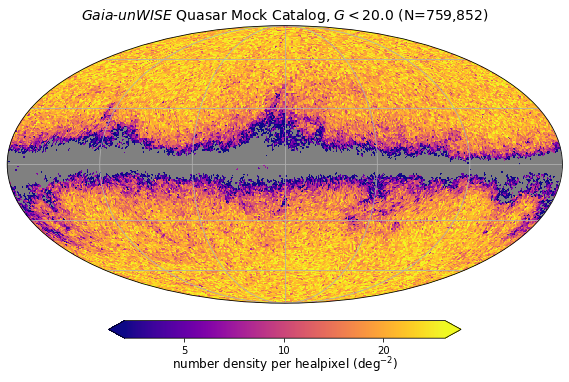

In [16]:
title_gcatlo = rf"{name_catalog}, $G<{G_lo}$ (N={len(tab_gcatlo):,})"
projview(map_gcatlo, title=title_gcatlo,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_gcatlo)-fac_stdev*np.std(map_gcatlo), max=np.median(map_gcatlo)+fac_stdev*np.std(map_gcatlo), 
            norm='log', graticule=True,
            cbar_ticks=[5, 10, 20]) 

In [17]:
pixel_indices_gcathi = hp.ang2pix(NSIDE, tab_gcathi['ra'], tab_gcathi['dec'], lonlat=True)
map_gcathi = np.bincount(pixel_indices_gcathi, minlength=NPIX)

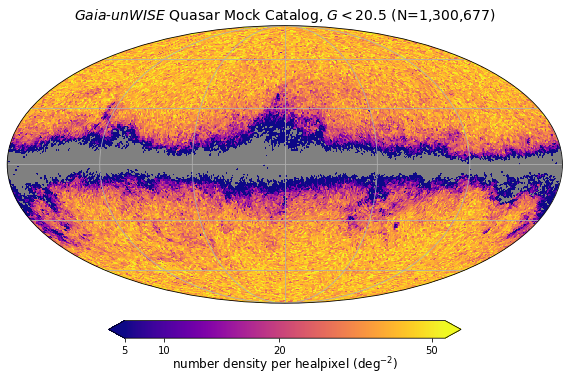

In [18]:
title_gcathi = rf"{name_catalog}, $G<{G_hi}$ (N={len(tab_gcathi):,})"
projview(map_gcathi, title=title_gcathi,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_gcathi)-fac_stdev*np.std(map_gcathi), max=np.median(map_gcathi)+fac_stdev*np.std(map_gcathi), 
            norm='log', graticule=True,
            cbar_ticks=[5, 10, 20, 50])

### Without the selection function

In [19]:
pixel_indices_gcatlo_nosel = hp.ang2pix(NSIDE, tab_gcatlo_nosel['ra'], tab_gcatlo_nosel['dec'], lonlat=True)
map_gcatlo_nosel = np.bincount(pixel_indices_gcatlo_nosel, minlength=NPIX)

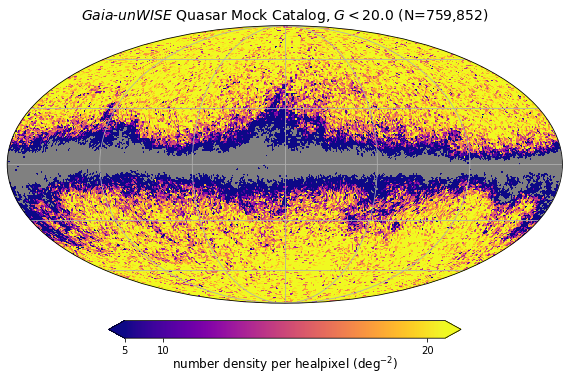

In [20]:
title_gcatlo_nosel = rf"{name_catalog}, $G<{G_lo}$ (N={len(tab_gcatlo_nosel):,})"
projview(map_gcatlo, title=title_gcatlo_nosel,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_gcatlo_nosel)-fac_stdev*np.std(map_gcatlo_nosel), max=np.median(map_gcatlo_nosel)+fac_stdev*np.std(map_gcatlo_nosel), 
            norm='log', graticule=True,
            cbar_ticks=[5, 10, 20]) 

In [21]:
pixel_indices_gcathi_nosel = hp.ang2pix(NSIDE, tab_gcathi_nosel['ra'], tab_gcathi_nosel['dec'], lonlat=True)
map_gcathi_nosel = np.bincount(pixel_indices_gcathi_nosel, minlength=NPIX)

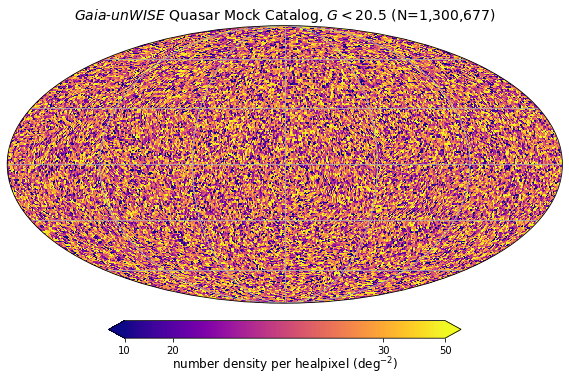

In [22]:
title_gcathi_nosel = rf"{name_catalog}, $G<{G_hi}$ (N={len(tab_gcathi_nosel):,})"
projview(map_gcathi_nosel, title=title_gcathi_nosel,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_gcathi_nosel)-fac_stdev*np.std(map_gcathi_nosel), max=np.median(map_gcathi_nosel)+fac_stdev*np.std(map_gcathi_nosel), 
            norm='log', graticule=True,
            cbar_ticks=[10, 20, 30, 50])

## Measure the mock clustering
### Start by calculating the projected overdensity contrast: $\delta_{g, p}=\frac{N_p}{\bar{N} w_p}-1,$ where $\bar{N}=\frac{\sum_p N_p}{\sum_p w_p}$

In [23]:
delta = map_gcatlo_nosel/np.mean(map_gcatlo_nosel)-1 # we can set wp = 1 since we are starting with no selection function!

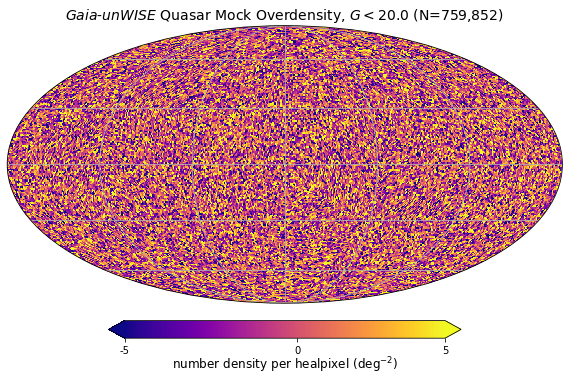

In [24]:
title_delta = rf"$Gaia$-$unWISE$ Quasar Mock Overdensity, $G<{G_lo}$ (N={len(tab_gcatlo_nosel):,})"
projview(delta, title=title_delta,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(delta)-fac_stdev*np.std(delta), max=np.median(delta)+fac_stdev*np.std(delta), 
            graticule=True,
            cbar_ticks=[-5, 0, 5]) 

### Compute the projected angular auto-power spectrum

In [25]:
# Create the bins array
rmin = 0.1
rmax = 20.0
nbins = 20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1)

In [26]:
results_DDtheta_mocks = mocks.DDtheta_mocks(autocorr = 1, nthreads = 2, binfile = rbins, 
                                            RA1 = tab_gcatlo_nosel['ra'], DEC1 = tab_gcatlo_nosel['dec'])

/home/mshiferaw/.local/lib/python3.8/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


In [29]:
results_DDrppi_mocks = mocks.DDrppi_mocks(autocorr = 1, cosmology = 2, nthreads = 2, pimax = 40.0, binfile = rbins, 
                                            RA1 = tab_gcatlo_nosel['ra'], DEC1 = tab_gcatlo_nosel['dec'], 
                                          CZ1 = constants.c*tab_gcatlo_nosel['redshift_quaia']/1000/100)

In [31]:
results_DDrppi_mocks

array([( 0.1       ,  0.13033213, 0.,  1.,     30102, 0.),
       ( 0.1       ,  0.13033213, 0.,  2.,     30306, 0.),
       ( 0.1       ,  0.13033213, 0.,  3.,     30040, 0.),
       ( 0.1       ,  0.13033213, 0.,  4.,     29512, 0.),
       ( 0.1       ,  0.13033213, 0.,  5.,     29990, 0.),
       ( 0.1       ,  0.13033213, 0.,  6.,     29358, 0.),
       ( 0.1       ,  0.13033213, 0.,  7.,     28996, 0.),
       ( 0.1       ,  0.13033213, 0.,  8.,     28514, 0.),
       ( 0.1       ,  0.13033213, 0.,  9.,     28442, 0.),
       ( 0.1       ,  0.13033213, 0., 10.,     28580, 0.),
       ( 0.1       ,  0.13033213, 0., 11.,     27526, 0.),
       ( 0.1       ,  0.13033213, 0., 12.,     27528, 0.),
       ( 0.1       ,  0.13033213, 0., 13.,     27502, 0.),
       ( 0.1       ,  0.13033213, 0., 14.,     26952, 0.),
       ( 0.1       ,  0.13033213, 0., 15.,     26514, 0.),
       ( 0.1       ,  0.13033213, 0., 16.,     26492, 0.),
       ( 0.1       ,  0.13033213, 0., 17.,     26606, 0.